<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB7_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Problem

In this assignment, you will demonstrate that adding a new constant predictor in the forward stagewise procedure to an already existing predictor from a previous stage, $f_{m-1}(x_i)$ (which we will denote as $f_i$ for ease of notation), may be for certain loss functions fundamentally more challenging than building a constant predictor from scratch. You will work with the binary cross-entropy loss defined as

$$
L(y, z) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z)),
$$


- $y_i \in \{0,1\}$ are the binary labels,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function.

where

- $y_i \in \{0,1\}$ are the binary labels,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function.

For the purposes of this assignment, assume that you are given:

- A dataset of binary labels $y_i$.
- **Two constants: $m$ (the number of ones) and $k$ (the number of zeros)** in the labels in the dataset.
- A set of predictions $f_i = f_{m-1}(x_i)$ obtained from a previous stage, where the $f_i$ values are generated randomly from a normal distribution.
### The assignment will explore two scenarios:

### Scenario A: Fitting a Constant Predictor from Scratch

In this scenario, you are building a predictor from scratch. The task is to find the optimal constant value $\lambda$ that minimizes the binary cross-entropy loss over the dataset. Formulate the optimization problem as:

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda).
$$



### Scenario B: Fitting the m-th Predictor in the Forward Stagewise Procedure

Now assume you already have an existing predictor $f_i = f_{m-1}(x_i)$. Rather than predicting from scratch, you wish to find an optimal additive correction $\lambda$ such that the updated prediction for each data point becomes

$$
 f_i + \lambda,
$$

and the corresponding binary cross-entropy loss is given by

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda).
$$


## Research Questions

In this assignment you will answer the following questions:

- Why is finding an optimal additive shift $\lambda$ in the forward stagewise procedure fundamentally harder than directly fitting a single-parameter predictor from scratch?
- How does the complexity of the loss landscape differ between these two scenarios? Discuss the differences in the shape and smoothness of the loss function in both cases.

# Derivation and analysis

## Scenario A

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda).
$$


Let's first derive some useful indetities.

$$
\frac{d}{dz}\sigma(z) = \frac{d}{dz}\left(\frac{1}{1 + e^{-z}}\right) = \frac{e^{-z}}{(1 + e^{-z})^2} = \sigma(z)\cdot (1 - \sigma(z)) \tag{1}
$$

&nbsp;
&nbsp;
&nbsp;


$$
\begin{aligned}
\frac{d}{dz}L(y, z)
&= \frac{d}{dz}\left(-y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z))\right) \\[6pt]
&= -y\frac{1}{\sigma(z)} \frac{d}{dz}(\sigma(z)) - (1-y)\frac{1}{1 - \sigma(z)}\frac{d}{dz}(1 - \sigma(z)) \\[6pt]
&\overset{(1)}{=} -y\frac{\sigma(z)(1 - \sigma(z))}{\sigma(z)} - (1-y)\frac{-\sigma(z)(1 - \sigma(z))}{1 - \sigma(z)} \\[6pt]
&= -y(1 - \sigma(z)) + (1 - y)\sigma(z) \\[6pt]
&= \sigma(z) - y
\end{aligned}\tag{2}
$$

&nbsp;

Now let's compute the derivative.

$$
\frac{d}{d\lambda}\sum_{i=1}^{n} L(y_i, \lambda) = \sum_{i=1}^{n} \frac{d}{d\lambda}L(y_i, \lambda) \overset{(2)}{=} \sum_{i=1}^{n} (\sigma(\lambda) - y_i)  = n\sigma(\lambda) - \sum_{i=1}^{n}y_i
$$

Therefore:

$$
\frac{d}{d\lambda}\sum_{i=1}^{n} L(y_i, \lambda) = 0 \\ \Updownarrow \\
\sigma(\lambda) = \frac{\sum_{i=1}^{n}y_i}{n} \\ \Updownarrow \\
\frac{1}{1 + e^{-\lambda}} = \frac{\sum_{i=1}^{n}y_i}{n} \\ \Updownarrow \\
1 + e^{-\lambda} = \frac{n}{\sum_{i=1}^{n}y_i} \\ \Updownarrow \\
e^{-\lambda} = \frac{n}{\sum_{i=1}^{n}y_i} - 1 \\ \Updownarrow \\
\lambda = -\log\left(\frac{n}{\sum_{i=1}^{n}y_i} - 1\right)
$$


Using the fact that among $(y_i)_{i=1}^n$ there are exactly $m$ ones and $k$ zeros and that binary cross-entropy is a convex function derive that the $\lambda^*$ minimizing loss is:
$$
\lambda^* =  -\log\left(\frac{n}{m} - 1\right)
$$

## Scenario B

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda).
$$

By repeating some steps of scenario A we get:
$$
\frac{d}{d\lambda}\sum_{i=1}^{n} L(y_i, f_i + \lambda) = \sum_{i=1}^{n}\sigma(f_i + \lambda) - \sum_{i=1}^{n}y_i
$$

So:
$$
\frac{d}{d\lambda}\sum_{i=1}^{n} L(y_i, f_i + \lambda) = 0 \\ \Updownarrow \\
\sum_{i=1}^{n}\sigma(f_i + \lambda) = \sum_{i=1}^{n}y_i \\ \Updownarrow \\
\sum_{i=1}^{n}\frac{1}{1 + e^{-f_i - \lambda}} = \sum_{i=1}^{n}y_i
$$

Which is not a trivial condition to solve even if we plug $\sum_{i=1}^{n}y_i = m$. Altough the problem looks analogous to scenario A, it is much harder to solve because having to consider:
$$\sum_{i=1}^{n} L(y_i, f_i + \lambda)$$
instead of:
$$\sum_{i=1}^{n} L(y_i, \lambda)$$

deprives us of the convenient property that:
$$
\frac{d}{dz}L(y, z)= \sigma(z) - y
$$
And when taking the sum over $i$, we can join all the $\sigma(z)$ expressions into $n\sigma(z)$. It is not the case in scenario B since $\sigma$ is not linear.



# Loss Landscape Exploration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
n = 100
m = 25
k = n - m

y = np.zeros(n)
y[:m] = 1

f = np.random.normal(0, 1, n)
lambdas = np.linspace(-7, 7, 100000)[:, None]

# Calculating the losses
loss_a = ((-y) * np.log(1/(1 + np.exp(-lambdas))) - (1-y)*np.log(1 - (1/(1 + np.exp(-lambdas))))).sum(axis= 1)
loss_b = ((-y) * np.log(1/(1 + np.exp(-(lambdas + f)))) - (1-y)*np.log(1 - (1/(1 + np.exp(-(lambdas + f)))))).sum(axis= 1)

# Evaluating the optimal lambdas
min_a = lambdas[np.argwhere(loss_a == loss_a.min())[0][0]][0]
min_b = lambdas[np.argwhere(loss_b == loss_b.min())[0][0]][0]

print(f"argmin lambda in scenario A: {min_a:.3f} (analytical solution: {-np.log(n/m - 1):.3f})")
print(f"argmin lambda in scenario B: {min_b:.3f}")


argmin lambda in scenario A: -1.099 (analytical solution: -1.099)
argmin lambda in scenario B: -1.179


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1447/3949583823.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.title("$L(\lambda)$")
/tmp/ipykernel_1447/3949583823.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


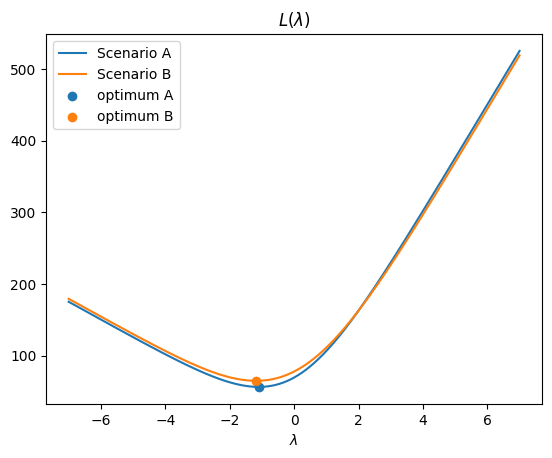

In [3]:
plt.plot(np.squeeze(lambdas), loss_a, label= "Scenario A")
plt.plot(np.squeeze(lambdas), loss_b, label= "Scenario B")
plt.scatter(min_a, loss_a.min(), label= "optimum A")
plt.scatter(min_b, loss_b.min(), label= "optimum B")
plt.title("$L(\lambda)$")
plt.xlabel("$\lambda$")
plt.legend()
plt.show()

As we can see, the loss landscape with regard to $\lambda$ is almost the same in both cases. Introducing the $f_i$ component did result in a problem that is much harder to solve analitically but the final fuction that is minimized is as simple as before. We can see that $L(\lambda)$ is unimodal and that can be proven.

We want $\lambda^*$ to satisfy:

$$
\sum_{i=1}^{n}\frac{1}{1 + e^{-f_i - \lambda}} = \sum_{i=1}^{n}y_i
$$

By putting $\sum_{i=1}^{n}y_i = C$ we can transform that condition to be:

$$
\sum_{i=1}^{n}\frac{e^{\lambda}}{e^{\lambda} + e^{-f_i}} = C
$$

Let's define:
$$
\phi(\lambda) = \sum_{i=1}^{n}\frac{e^{\lambda}}{e^{\lambda} + e^{-f_i}} - C
$$

$$
\frac{d}{d\lambda}\phi(\lambda) = \sum_{i=1}^{n}\frac{e^{\lambda}(e^{\lambda} + e^{-f_i}) - e^{\lambda}(e^{\lambda})}{(e^{\lambda} + e^{-f_i})^2} = \sum_{i=1}^{n}\frac{e^{-f_i}}{(e^{\lambda} + e^{-f_i})^2} > 0
$$

Since $\frac{d}{d\lambda}\phi(\lambda)$ is strictly positive, there cannot exist more than one root of $\phi$, which means that there cannot exist more than one minimum for the loss. $\phi$ is also smooth, so using numerical approximation of $\lambda^*$ will work well.